# 🏞️ **River Water Quality Prediction and Contamination Detection using **Machine** Learning**

## 🌌 **Group Members:**

1. **Muhammad Naqib Syahmi bin Ab Razak 23073950**
2. **Long Yun 24213952**
3. **An Lulu 24236510**
4. **Wei Zihan 24233259**
5. **Xie Zhicheng 23093258**

## 🎛️ **Preliminaries**

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Feature preprocessing and data splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial import cKDTree

# Machine Learning & Deep Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb


from datetime import date
from tqdm import tqdm
import os

### 📍 **In-Situ Measurements Data**

In [3]:
base_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(base_dir, "data")

In [5]:
Water_Quality_df = pd.read_csv(os.path.join(data_dir, "Combined_dataset.csv"))
Water_Quality_df.head()

,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,Canada,SE649035-145565,River,12-01-1974,0.059248,1.30,8.1500,0.011917,8.07500,9.885,0.343917,11.73155,100.0,Excellent
1,Canada,SE649035-145565,River,12-01-1975,0.039821,1.38,7.8000,0.009417,7.73333,10.150,0.449083,11.82009,100.0,Excellent
2,Canada,SE649035-145565,River,12-01-1976,0.031341,2.23,7.8000,0.011000,7.46667,10.235,0.220750,14.87472,100.0,Excellent
3,Canada,SE649035-145565,River,12-01-1977,0.020501,1.61,8.1500,0.012333,7.78333,11.116,0.572250,15.89293,100.0,Excellent
4,Canada,SE649035-145565,River,12-01-1978,0.020023,1.64,4.3708,0.006182,7.10000,7.068,0.371091,15.22888,100.0,Excellent


In [6]:
# Preparing water quality data
Water_Quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           object 
 1   Area                              object 
 2   Waterbody Type                    object 
 3   Date                              object 
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          object 
dtypes: float64(9), object(5)
memory usage: 302.1+ MB


In [7]:
# To filter data from 2000 to 2025
Water_Quality_df['Date'] = pd.to_datetime(Water_Quality_df['Date'], format='%d-%m-%Y')
Water_Quality_df = Water_Quality_df[(Water_Quality_df['Date'] >= '2000-01-01') & (Water_Quality_df['Date'] <= '2025-12-31')]
Water_Quality_df = Water_Quality_df.reset_index(drop=True)

In [8]:
Water_Quality_df.info()
Water_Quality_df["Date"].min(), Water_Quality_df["Date"].max()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2584888 entries, 0 to 2584887
Data columns (total 14 columns):
 #   Column                            Dtype         
---  ------                            -----         
 0   Country                           object        
 1   Area                              object        
 2   Waterbody Type                    object        
 3   Date                              datetime64[ns]
 4   Ammonia (mg/l)                    float64       
 5   Biochemical Oxygen Demand (mg/l)  float64       
 6   Dissolved Oxygen (mg/l)           float64       
 7   Orthophosphate (mg/l)             float64       
 8   pH (ph units)                     float64       
 9   Temperature (cel)                 float64       
 10  Nitrogen (mg/l)                   float64       
 11  Nitrate (mg/l)                    float64       
 12  CCME_Values                       float64       
 13  CCME_WQI                          object        
dtypes: datetime64[ns](

(Timestamp('2000-01-01 00:00:00'), Timestamp('2023-12-17 00:00:00'))

In [9]:
# To filter data to include only River waterbody type
River_Water_Quality_df = Water_Quality_df[Water_Quality_df['Waterbody Type'] == 'River']
River_Water_Quality_df = River_Water_Quality_df.reset_index(drop=True)
River_Water_Quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629890 entries, 0 to 1629889
Data columns (total 14 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   Country                           1629890 non-null  object        
 1   Area                              1629890 non-null  object        
 2   Waterbody Type                    1629890 non-null  object        
 3   Date                              1629890 non-null  datetime64[ns]
 4   Ammonia (mg/l)                    1629890 non-null  float64       
 5   Biochemical Oxygen Demand (mg/l)  1629890 non-null  float64       
 6   Dissolved Oxygen (mg/l)           1629890 non-null  float64       
 7   Orthophosphate (mg/l)             1629890 non-null  float64       
 8   pH (ph units)                     1629890 non-null  float64       
 9   Temperature (cel)                 1629890 non-null  float64       
 10  Nitrogen (mg/l)   

In [10]:
# Save filtered data to CSV
River_Water_Quality_df.to_csv(os.path.join(data_dir, "River_Water_Quality.csv"), index=False)

### 📍 **Filtered In-Situ Measurement Data (Keep Date between 2000 - 2023 and Keep River Waterbody Type)**

In [11]:
River_Water_Quality_df = pd.read_csv(os.path.join(data_dir, "River_Water_Quality.csv"))
River_Water_Quality_df.head()

,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,Canada,LI110048,River,2000-01-12,0.05152,3.90760,11.684103,0.01,8.3700,10.00,0.241667,9.73940,100.0,Excellent
1,Canada,LI110048,River,2001-01-12,0.06440,3.33070,8.800000,0.01,8.1667,10.27,0.276000,10.62480,100.0,Excellent
2,Canada,LI110048,River,2002-01-12,0.07728,3.19160,10.033300,0.01,8.0167,10.00,0.319000,8.72119,100.0,Excellent
3,Canada,LI110048,River,2003-01-12,0.09016,3.77391,11.475000,0.01,7.7900,8.68,0.202000,9.51805,100.0,Excellent
4,Canada,LI110048,River,2004-01-12,0.10304,5.06000,11.733300,0.01,8.1583,8.43,0.355000,8.63265,100.0,Excellent


## 🛠️ **Data Preprocessing**

In [12]:
# Check for missing values
missing_values = River_Water_Quality_df.isna().sum()
print("\n Missing values in each column")
print(missing_values)


 Missing values in each column
Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64


In [13]:
# (If there is missing values) For numeric columns, fill missing values with their mean
numeric_cols = River_Water_Quality_df.select_dtypes(include=['number']).columns

River_Water_Quality_df[numeric_cols] = River_Water_Quality_df[numeric_cols].fillna(River_Water_Quality_df[numeric_cols].mean())

In [14]:
# Check number of unique countries in the dataset
country = River_Water_Quality_df["Country"].unique()
print(country)

['Canada' 'England' 'USA' 'Ireland']


## 📊 **Exploratory Data Analysis (EDA)**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Date conversion and filtering
# Converting to datetime and dropping invalid dates immediately
River_Water_Quality_df['Date'] = pd.to_datetime(River_Water_Quality_df['Date'], errors='coerce')
River_Water_Quality_df = River_Water_Quality_df.dropna(subset=['Date'])

# Create a sample for visualization
# We sample 10,000 records to ensure plots are generated quickly
River_Water_Quality_df_sample = River_Water_Quality_df.sample(n=10000, random_state=42)

print(f"Dataset successfully loaded. Total records (2000-2023): {len(River_Water_Quality_df)}")

Dataset successfully loaded. Total records (2000-2023): 1629890


In [16]:
River_Water_Quality_df.head(10)

,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,Canada,LI110048,River,2000-01-12,0.05152,3.90760,11.684103,0.01,8.3700,10.00,0.241667,9.73940,100.0,Excellent
1,Canada,LI110048,River,2001-01-12,0.06440,3.33070,8.800000,0.01,8.1667,10.27,0.276000,10.62480,100.0,Excellent
2,Canada,LI110048,River,2002-01-12,0.07728,3.19160,10.033300,0.01,8.0167,10.00,0.319000,8.72119,100.0,Excellent
3,Canada,LI110048,River,2003-01-12,0.09016,3.77391,11.475000,0.01,7.7900,8.68,0.202000,9.51805,100.0,Excellent
4,Canada,LI110048,River,2004-01-12,0.10304,5.06000,11.733300,0.01,8.1583,8.43,0.355000,8.63265,100.0,Excellent
5,Canada,LI110048,River,2005-01-12,0.10304,4.43182,11.433300,0.01,7.7900,9.84,0.303000,8.76546,100.0,Excellent
6,Canada,LI110048,River,2006-01-12,0.10304,4.36364,8.691000,0.01,7.7615,10.35,0.281000,12.83830,100.0,Excellent
7,Canada,LI110048,River,2007-01-12,0.11592,1.41667,10.730000,0.02,7.7900,10.75,0.415000,9.07535,100.0,Excellent
8,Canada,LI110048,River,2008-01-12,0.12880,1.33333,10.616700,0.02,7.4000,8.35,0.343000,11.42166,100.0,Excellent
9,Canada,LI110048,River,2009-01-12,0.07728,1.56670,9.445600,0.01,7.7900,9.72,0.239000,9.20816,100.0,Excellent


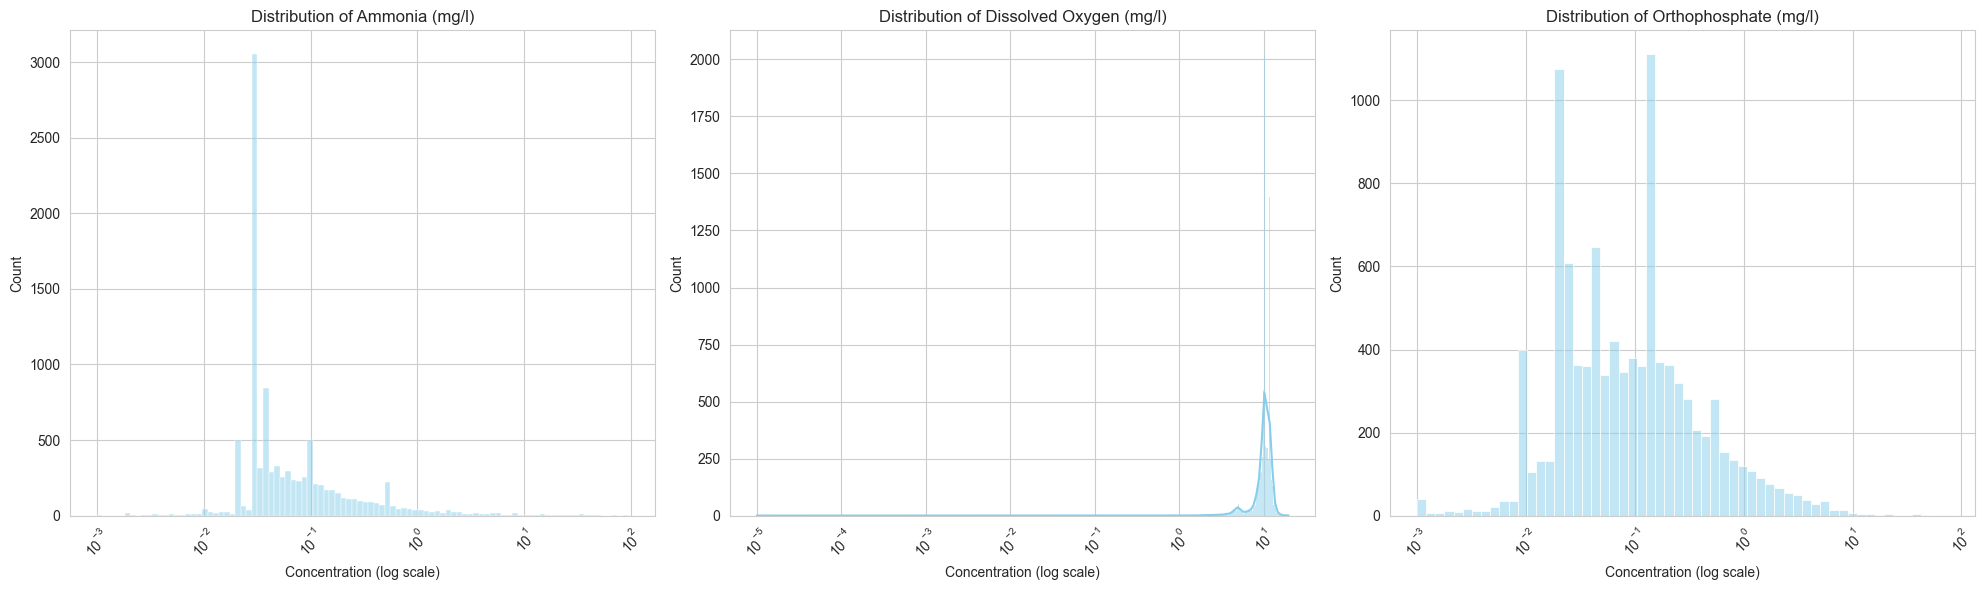

In [17]:
# EDA 1: Univariate Distribution Analysis This helps identify outliers and the distribution shape of key metrics.
# Set plot style
sns.set_style("whitegrid")

# Select numeric columns
cols_to_plot = ['Ammonia (mg/l)', 'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)']

# Create subplots with adjusted spacing
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols_to_plot):
    if col in River_Water_Quality_df_sample.columns:
        # Use log_scale=True to handle skewed water quality data
        # This makes the distribution visible instead of one giant spike
        sns.histplot(River_Water_Quality_df_sample[col], kde=True, ax=axes[i], color='skyblue', log_scale=True)

        # Set title and labels
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('Concentration (log scale)')

        # Rotate x-axis labels to prevent overlap
        axes[i].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

⭐️ **Interpretation of EDA 1**

From the distribution plots, Ammonia and Orthophosphate show clear right-skewed distributions, where most observations are concentrated at lower concentration levels while a smaller number of samples contain much higher values. This suggests that water quality is generally within normal conditions, although occasional pollution spikes or contamination events are present.

Dissolved Oxygen (DO) is more concentrated around higher values, indicating relatively healthy oxygen conditions in most water samples, with only a few lower-value observations suggesting possible environmental stress.

In [18]:
# EDA 2: Time Series Trend Analysis Observing how water quality metrics have evolved over the years.
# Extract year and calculate the yearly average
River_Water_Quality_df['Year'] = River_Water_Quality_df['Date'].dt.year

# Group by Year and Country
yearly_country_avg = River_Water_Quality_df.groupby(['Year', 'Country'])[['Ammonia (mg/l)', 'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)']].mean().reset_index()

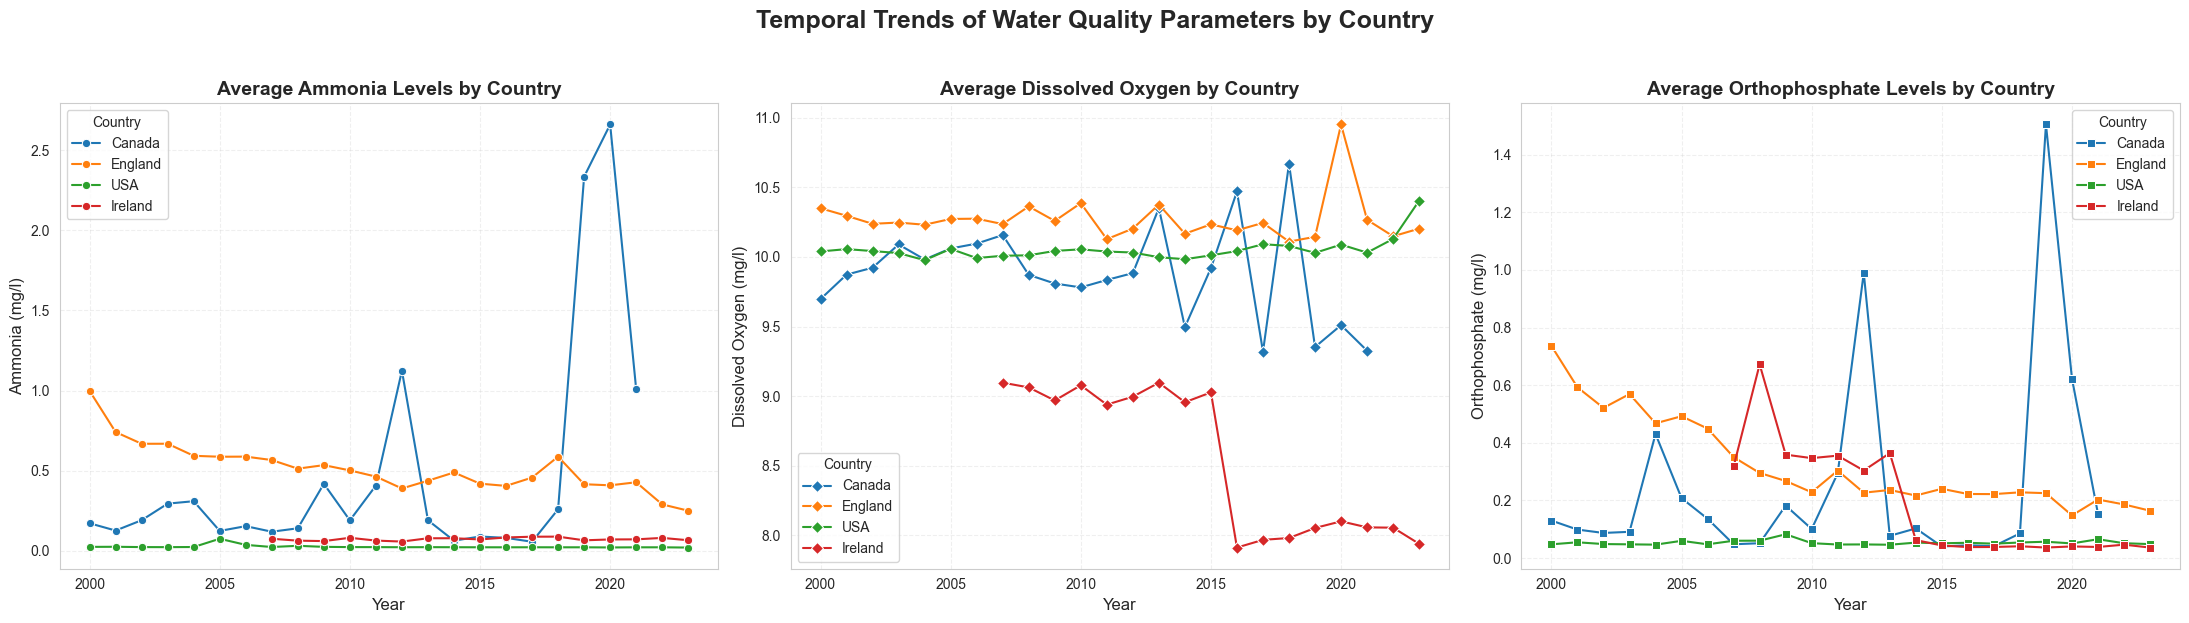

In [19]:
# Plot Trends
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

# --- Plot 1: Ammonia Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='Ammonia (mg/l)',
             hue='Country', marker='o', ax=axes[0])

axes[0].set_title('Average Ammonia Levels by Country', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Ammonia (mg/l)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.3)

# --- Plot 2: Dissolved Oxygen Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='Dissolved Oxygen (mg/l)',
             hue='Country', marker='D', ax=axes[1])

axes[1].set_title('Average Dissolved Oxygen by Country', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Dissolved Oxygen (mg/l)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.3)

# --- Plot 3: Orthophosphate Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='Orthophosphate (mg/l)',
             hue='Country', marker='s', ax=axes[2])

axes[2].set_title('Average Orthophosphate Levels by Country', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Orthophosphate (mg/l)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.3)

fig.suptitle(
    'Temporal Trends of Water Quality Parameters by Country',
    fontsize=18,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

⭐️ **Interpretation of EDA 2**

The temporal trend plots indicate that ammonia and orthophosphate concentrations generally decrease over time in several countries, suggesting improvements in water quality and reduced nutrient pollution. However, some noticeable spikes are still present, particularly in Canada, indicating occasional pollution events or fluctuations in environmental conditions.

Dissolved oxygen levels remain relatively stable across the years, with most countries maintaining values around healthy ranges for rivers. Minor fluctuations are obsered, but overall oxygen conditions appear consistent.

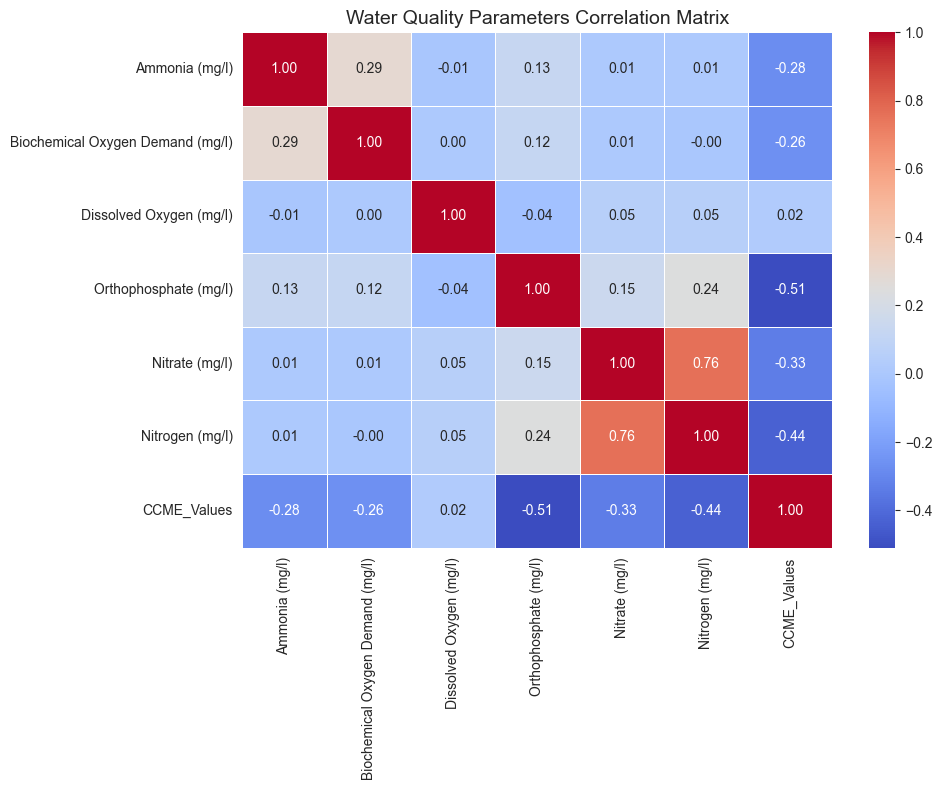

In [20]:
# EDA 3: Correlation Analysis Using a heatmap to identify linear relationships between features.
# Define selected features
selected_features = ['Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)', 'Dissolved Oxygen (mg/l)',
                     'Orthophosphate (mg/l)', 'Nitrate (mg/l)', 'Nitrogen (mg/l)',
                     'Temperature', 'pH', 'CCME_Values'
]

# Keep only existing columns
selected_features = [col for col in selected_features if col in River_Water_Quality_df.columns]

# Create subset
subset_df = River_Water_Quality_df[selected_features]

# Compute correlation
corr_matrix = subset_df.corr()

# Plot full heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt=".2f", linewidths=0.5
)

plt.title('Water Quality Parameters Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

⭐️ **Interpretation of EDA 3**

The correlation matrix shows that nitrate and nitrogen have a strong positive correlation, indicating that these nutrient-related parameters tend to increase together and may originate from similar pollution sources such as river wastewater discharge. Orthophosphate also shows moderate positive correlations with nitrate and nitrogen, suggesting interconnected nutrient pollution dynamics.

Most pollution-related parameters, including ammonia, orthophosphate, nitrate, and nitrogen, exhibit negative correlations with the CCME Water Quality Index, indicating that higher pollutant concentrations are associated with poorer water quality conditions. Among these, orthophosphate and nitrogen demonstrate relatively stronger negative relationships with water quality index (WQI).

In contrast, Dissolved Oxygen shows a slight positive correlation with WQI, suggesting that higher oxygen levels are generally associated with healthier river environments.

## ⚙️ **Model Training**

**Regression models** are designed to handle problem with numeric target variable. To access predictive performance and interpretability, different regression model will be compared.

Model | Description
--- | ---
**Random Forest** | Non-linear model that handles complex relationship between variables.
**XGBoost** | An optimized gradient boosting framework that offers regularization and high performance for structured data problems
**Hybrid CNN-XGBoost** | A hybrid model that combines Convolutional Neural Network (CNN) based feature extraction with XGBoost regression to capture complex patterns and improve predictive performance


In [21]:
df_base_clean = River_Water_Quality_df.copy()

# Format Date column
df_base_clean['Date'] = pd.to_datetime(df_base_clean['Date'])

# Drop rows missing target values
df_base_clean = df_base_clean.dropna(subset=['CCME_Values'])

# Fill missing values for numerical columns with mean
numeric_cols = df_base_clean.select_dtypes(include=['number']).columns
df_base_clean[numeric_cols] = df_base_clean[numeric_cols].fillna(df_base_clean[numeric_cols].mean())

# Drop the classification target to prevent target leakage
if 'CCME_WQI' in df_base_clean.columns:
    df_base_clean = df_base_clean.drop(columns=['CCME_WQI'])

print(f"Common dataframe generated successfully. Shape: {df_base_clean.shape}")
df_base_clean.head()

Common dataframe generated successfully. Shape: (1629890, 14)


,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,Year
0,Canada,LI110048,River,2000-01-12,0.05152,3.90760,11.684103,0.01,8.3700,10.00,0.241667,9.73940,100.0,2000
1,Canada,LI110048,River,2001-01-12,0.06440,3.33070,8.800000,0.01,8.1667,10.27,0.276000,10.62480,100.0,2001
2,Canada,LI110048,River,2002-01-12,0.07728,3.19160,10.033300,0.01,8.0167,10.00,0.319000,8.72119,100.0,2002
3,Canada,LI110048,River,2003-01-12,0.09016,3.77391,11.475000,0.01,7.7900,8.68,0.202000,9.51805,100.0,2003
4,Canada,LI110048,River,2004-01-12,0.10304,5.06000,11.733300,0.01,8.1583,8.43,0.355000,8.63265,100.0,2004


**Cross-sectional Data Pipeline**

This data pipeline branch prepares the flat, tabular dataset specifically designed for the machine learning models (Random Forest, XGBoost, and Hybrid CNN-XGBoost). Unused columms (`Area`, `Country`, `Waterbody Type`, `Date`, `Area`) are removed from the dataset

In [ ]:
df_baseline = df_base_clean.copy()

# Drop unused columns
cols_to_drop = ['Country', 'Waterbody Type', 'Date', 'Area']
df_baseline = df_baseline.drop(columns=[col for col in cols_to_drop if col in df_baseline.columns])

# Export clean data for ML modeling
df_baseline.to_csv(os.path.join(data_dir, "River_Water_Quality_df_Final.csv"), index=False)

,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,Year
0,0.05152,3.90760,11.684103,0.01,8.3700,10.00,0.241667,9.73940,100.0,2000
1,0.06440,3.33070,8.800000,0.01,8.1667,10.27,0.276000,10.62480,100.0,2001
2,0.07728,3.19160,10.033300,0.01,8.0167,10.00,0.319000,8.72119,100.0,2002
3,0.09016,3.77391,11.475000,0.01,7.7900,8.68,0.202000,9.51805,100.0,2003
4,0.10304,5.06000,11.733300,0.01,8.1583,8.43,0.355000,8.63265,100.0,2004


In [24]:
df_baseline = pd.read_csv(os.path.join(data_dir, "River_Water_Quality_df_Final.csv"))
df_baseline.head()

,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,Year
0,0.05152,3.90760,11.684103,0.01,8.3700,10.00,0.241667,9.73940,100.0,2000
1,0.06440,3.33070,8.800000,0.01,8.1667,10.27,0.276000,10.62480,100.0,2001
2,0.07728,3.19160,10.033300,0.01,8.0167,10.00,0.319000,8.72119,100.0,2002
3,0.09016,3.77391,11.475000,0.01,7.7900,8.68,0.202000,9.51805,100.0,2003
4,0.10304,5.06000,11.733300,0.01,8.1583,8.43,0.355000,8.63265,100.0,2004


### 🧪 **Random Forest Regressor**

In [ ]:
# Load clean data
df_rf = df_baseline.copy()

exclude_cols = ['CCME_Values']
feature_cols = [col for col in df_rf.columns if col not in exclude_cols]

X_rf = df_rf[feature_cols]
y_rf = df_rf['CCME_Values']

print(f"Random Forest Input - X shape: {X_rf.shape} | y shape: {y_rf.shape}")

In [ ]:
# Define categorical and numerical features

# Build preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_rf.columns),
    ])

# Build Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, max_depth=6, max_features=0.8,
                                        max_samples=0.8, random_state=42, n_jobs=-1))
])

print("Random Forest Pipeline built.")

In [ ]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

print(f"Training Random Forest on {X_train_rf.shape[0]} samples...")

# Fit model
rf_pipeline.fit(X_train_rf, y_train_rf)

print("Random Forest Training complete.")

### ✅ **Model Evaluation and Visual Analysis**
We evaluate the model's performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Feature Importance) to clearly interpret the results and identify which data indicators are the main drivers of the water quality index.

In [ ]:
# Predict on test set
y_pred_rf = rf_pipeline.predict(X_test_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("--- Random Forest (Baseline) Evaluation Results ---")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sample_size = min(2000, len(y_test_rf))

sample_idx = np.random.choice(len(y_test_rf), size=sample_size, replace=False)

y_test_rf_sample = (y_test_rf.iloc[sample_idx] if isinstance(y_test_rf, pd.Series) else y_test_rf[sample_idx])

y_pred_rf_sample = y_pred_rf[sample_idx]

axes[0].scatter(y_test_rf_sample, y_pred_rf_sample, alpha=0.4,
                color='royalblue', edgecolors='k')

min_val = min(y_test_rf_sample.min(), y_pred_rf_sample.min())
max_val = max(y_test_rf_sample.max(), y_pred_rf_sample.max())

axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

axes[0].set_title('Random Forest: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual CCME Values', fontsize=12)
axes[0].set_ylabel('Predicted CCME Values', fontsize=12)

# Plot 2: Feature Importance
rf_model = rf_pipeline.named_steps['regressor']

feature_names = X_rf.columns.tolist()

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

top_n = min(10, len(feature_names))
top_features = np.array(feature_names)[indices][:top_n]
top_importances = importances[indices][:top_n]

sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette='viridis')

axes[1].set_title('Random Forest: Top 10 Feature Importances', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Importance', fontsize=12)
axes[1].set_ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

### 🧪 **XGBoost Regressor**

In [ ]:
import xgboost as xgb

df_xgb = df_baseline.copy()

exclude_cols = ['CCME_Values']
feature_cols = [col for col in df_xgb.columns if col not in exclude_cols]

X_xgb = df_xgb[feature_cols]
y_xgb = df_xgb['CCME_Values']

print(f"XGBoost Input - X shape: {X_xgb.shape} | y shape: {y_xgb.shape}")

In [ ]:
# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_xgb.columns)
    ])

# Define XGBoost pipeline
# n_jobs=-1 uses all available CPU cores
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   objective='reg:squarederror', n_jobs=-1))
])

print("XGBoost Pipeline built.")

In [ ]:
# Train-test split
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

print(f"Training XGBoost on {X_train_xgb.shape[0]} samples...")

# Fit model
xgb_pipeline.fit(X_train_xgb, y_train_xgb)

print("XGBoost Training complete.")

### ✅ **Model Evaluation and Visual Analysis**
We evaluate the model's performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Feature Importance) to clearly interpret the results and identify which data indicators are the main drivers of the water quality index.

In [ ]:
# Predict on test set
y_pred_xgb = xgb_pipeline.predict(X_test_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
r2_xgb = r2_score(y_test_xgb, y_pred_xgb)

print("--- XGBoost (Baseline) Evaluation Results ---")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"R2 Score: {r2_xgb:.4f}")

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sample_size = min(2000, len(y_test_xgb))

sample_idx = np.random.choice(len(y_test_xgb), size=sample_size, replace=False)

y_test_xgb_sample = (y_test_xgb.iloc[sample_idx] if isinstance(y_test_xgb, pd.Series) else y_test_xgb[sample_idx])

y_pred_xgb_sample = y_pred_xgb[sample_idx]

axes[0].scatter(y_test_xgb_sample, y_pred_xgb_sample, alpha=0.4,
                color='darkorange', edgecolors='black')

min_val = min(y_test_xgb_sample.min(), y_pred_xgb_sample.min())
max_val = max(y_test_xgb_sample.max(), y_pred_xgb_sample.max())

axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

axes[0].set_title('XGBoost: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual CCME Values', fontsize=12)
axes[0].set_ylabel('Predicted CCME Values', fontsize=12)

# Plot 2: Feature Importance
xgb_model = xgb_pipeline.named_steps['regressor']

feature_names = X_xgb.columns.tolist()

importances = xgb_model.feature_importances_

indices = np.argsort(importances)[::-1]

top_n = min(10, len(feature_names))
top_features = np.array(feature_names)[indices][:top_n]
top_importances = importances[indices][:top_n]

sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette='magma')

axes[1].set_title('XGBoost: Top 10 Feature Importances', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Importance', fontsize=12)
axes[1].set_ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

### 🧪 **Hybrid CNN-XGBoost Model**
1. **CNN:** Trained to capture complex patterns and feature interactions from the input data.
2. **Feature Extraction:** Dense feature representations are extracted from the CNN's layer.
3. **XGBoost:** An XGBoost regressor is trained using these high-level extracted features to generate the final prediction.

In [ ]:
df_hybrid = df_baseline.copy()

df_hybrid.head()

In [ ]:
df_hybrid = df_baseline.copy()

exclude_cols = ['CCME_Values']
feature_cols = [col for col in df_hybrid.columns if col not in exclude_cols]

X_hybrid = df_hybrid[feature_cols]
y_hybrid = df_hybrid['CCME_Values']

# Train-test split
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid, y_hybrid, test_size=0.2, random_state=42)
print(f"Train size: {X_train_hybrid.shape[0]} | Test size: {X_test_hybrid.shape[0]}")

In [ ]:
scaler = StandardScaler()

X_train_hybrid_scaled = scaler.fit_transform(X_train_hybrid)
X_test_hybrid_scaled = scaler.fit_transform(X_test_hybrid)

In [ ]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_hybrid_scaled, y_train_hybrid, test_size=0.1, random_state=42)

In [ ]:
# Data Preparation

# PyTorch CNN requires (Samples, Features) input format

# --- Training tensors ---
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train_final.values, dtype=torch.float32).view(-1, 1)

# --- Validation tensors ---
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# --- Test tensors ---
X_test_tensor = torch.tensor(X_test_hybrid_scaled, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test_hybrid.values, dtype=torch.float32).view(-1, 1)

# Create DataLoader for batch training to optimize memory
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=True)

In [ ]:
# Define Hybrid CNN Architecture

class WaterQualityCNN(nn.Module):
  def __init__(self, num_features):
    super(WaterQualityCNN, self).__init__()
    # Convolutional layer to extract features
    self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm1d(32)

    self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm1d(64)
    self.relu = nn.ReLU()

    self.dropout = nn.Dropout(0.3)

    # Reduces feature dimension
    self.pool = nn.AdaptiveAvgPool1d(1)
    self.flatten = nn.Flatten()

    # Feature extraction layer (Extracts 32D high-level features)
    self.fc_features = nn.Linear(64, 32)

    # Regression output layer for CNN pre-training
    self.fc_output = nn.Linear(32, 1)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)

    # Global pooling
    x = self.pool(x)

    # Flatten
    x = self.flatten(x)

    # Feature extraction
    features = self.dropout(self.relu(self.fc_features(x)))

    # Output
    output = self.fc_output(features)

    return output, features

In [ ]:
# Initialize hybrid model
num_features = X_train_tensor.shape[2]

hybrid_cnn_xgb_model = WaterQualityCNN(num_features)

print(hybrid_cnn_xgb_model)

In [ ]:
# --- CNN Training ---

criterion = nn.MSELoss()

optimizer = optim.Adam(hybrid_cnn_xgb_model.parameters(), lr=0.001)

epochs = 50
patience = 5
best_val_loss = float('inf')
counter = 0

print("Training CNN Model...")

for epoch in range(epochs):
    # --- TRAINING ---
    hybrid_cnn_xgb_model.train()
    train_loss = 0.0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)

    for batch_X, batch_y in train_progress:
        optimizer.zero_grad()

        outputs, _ = hybrid_cnn_xgb_model(batch_X)

        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        train_progress.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION ---
    hybrid_cnn_xgb_model.eval()
    val_loss = 0.0

    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)

    with torch.no_grad():

        for val_X, val_y in val_progress:

            val_outputs, _ = hybrid_cnn_xgb_model(val_X)

            loss = criterion(val_outputs, val_y)
            val_loss += loss.item()

            val_progress.set_postfix(val_loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)

    # Epoch summary
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        counter = 0

        torch.save(hybrid_cnn_xgb_model.state_dict(), "best_hybrid_cnn_xgb.pth")

        print("Validation loss improved. Model saved.")

    else:

        counter += 1
        print(f"Early Stopping Counter: " f"{counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

In [ ]:
model_dir = os.path.join(base_dir, "models")

# Load hybrid model
hybrid_cnn_xgb_model.load_state_dict(torch.load(os.path.join(model_dir, "best_hybrid_cnn_xgb.pth")))

In [ ]:
# Extract Features & Train XGBoost

print("Extracting CNN Features...")

hybrid_cnn_xgb_model.eval()

with torch.no_grad():
    _, train_cnn_features = hybrid_cnn_xgb_model(X_train_tensor)
    _, test_cnn_features = hybrid_cnn_xgb_model(X_test_tensor)

# Convert tensors to numpy arrays
train_hybrid_cnn_xgb_features_np = train_cnn_features.numpy()
test_hybrid_cnn_xgb_features_np = test_cnn_features.numpy()

print(f"Extracted features shape: {train_hybrid_cnn_xgb_features_np.shape}")

# Train Hybrid CNN-XGBoost Regressor
print("Training Hybrid CNN-XGBoost: ")

hybrid_cnn_xgb = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8, random_state=42,
                              objective='reg:squarederror', n_jobs=-1)

hybrid_cnn_xgb.fit(train_hybrid_cnn_xgb_features_np, y_train_final)

### ✅ **Model Evaluation and Visual Analysis**
We evaluate the model's performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Feature Importance) to clearly interpret the results and identify which data indicators are the main drivers of the water quality index.

In [ ]:
# Predict on test set
y_pred_hybrid = hybrid_cnn_xgb.predict(test_hybrid_cnn_xgb_features_np)

rmse_hybrid = np.sqrt(mean_squared_error(y_test_hybrid, y_pred_hybrid))
mae_hybrid = mean_absolute_error(y_test_hybrid, y_pred_hybrid)
r2_hybrid = r2_score(y_test_hybrid, y_pred_hybrid)

print("Hybrid CNN-XGBoost (Main) Evaluation Results: ")
print(f"RMSE: {rmse_hybrid:.4f}")
print(f"MAE:  {mae_hybrid:.4f}")
print(f"R2 Score: {r2_hybrid:.4f}")

## ⭐️ **Interpretation of Results**

**1. Performance Overview**

In this section, the baseline models (Random Forest and XGBoost) are compared with the proposed Hybrid CNN-XGBoost model. Model performance are evaluated using standard regression metrics including R2, RMSE, and MAE.

The results show that all models achieved strong predictive performance, with XGBoost producing the highest overall accuracy, followed by Random Forest and the Hybrid CNN-XGBoost model.

**2. Key Insights & Discussion**

* **XGBoost Performance**: The XGBoost model achieved the best predictive performance with an R2 = 0.9986, indicating an almost perfect fit to the dataset. Its low RMSE and MAE values suggest that XGBoost was highly effective in capturing complex non-linear relationships within the structured environmental and water quality data.

* **Random Forest Performance**: The Random Forest model also demonstrated strong predictive capability with an R2 = 0.9917. Although slightly lower than XGBoost, the model remained highly accurate and robust for predicting CCME water quality values.

* **Hybrid CNN-XGBoost Performance**: The proposed Hybrid CNN-XGBoost model achieved strong overall performance with an R2 = 0.9644, demonstrating that the model was capable of learning meaningful feature representations from the dataset before performing regression using XGBoost. However, its performance was slightly lower compared to the standalone XGBoost and Random Forest models.

* **Discussion**: The baseline machine learning models were trained directly on structured tabular data, which is highly suitable for tree-based algorithms such as Random Forest and XGBoost. In contrast, the CNN component in the hybrid architecture introduces an additional feature extraction stage that may not provide substantial advantages for non-sequential cross-sectional data. Since the dataset does not contain strong temporal or spatial patterns, the deep learning feature extraction process may introduce additional complexity without significantly improving predictive accuracy.

* Overall, the findings suggest that traditional ensemble learning models, particularly XGBoost, are highly effective for structured environmental and water quality datasets. While the Hybrid CNN-XGBoost model remains capable of achieving strong predictive performance, the results indicate that more complex hybrid deep learning architectures do not necessarily outperform optimized gradient boosting models for cross-sectional tabular data.